# Pré-processamento EEG — BrainLat (versão segura para classificação)

Pipeline com foco em reduzir vazamento de dados para modelos de ML/IA.

Regras centrais:
- nenhum rótulo em nome de arquivo de saída;
- `path`, `grupo` e `país` ficam apenas no manifesto;
- split por sujeito na etapa de ML;
- testes de sanidade em cada etapa crítica.

In [10]:
import os
import re
import json
import glob
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

# Ajuste apenas estes caminhos
RAW_ROOT_AD = Path(r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_alzheimer")
RAW_ROOT_HC = Path(r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\dataset_eeg_hc")

OUT_ROOT = Path(r"C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\preprocessado_seguros")
EPOCHS_ROOT = OUT_ROOT / "epochs"
REPORTS_ROOT = OUT_ROOT / "reports"
MANIFEST_PATH = OUT_ROOT / "manifesto_preprocessado.csv"
LOG_PATH = OUT_ROOT / "log_preprocessamento.csv"

for p in [OUT_ROOT, EPOCHS_ROOT, REPORTS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

# Parâmetros
SFREQ_ALVO = 512
FILTRO_HP = 0.5
FILTRO_LP = 40.0
ORDEM_FILTRO = 8
DURACAO_EPOC = 2.0
LIMIAR_P2P = 150e-6
N_COMPONENTES_ICA = 20
LIMIAR_CANAL_DP = 3.0
RANDOM_STATE = 42

print("Configuração carregada.")
print(f"Saída em: {OUT_ROOT}")

Configuração carregada.
Saída em: C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\preprocessado_seguros


## 1 — Inventário dos arquivos e criação do manifesto-base

Os rótulos são preservados somente no manifesto.  
Os arquivos de saída usam `sample_id` neutro.

In [11]:
def inferir_pais(caminho: Path) -> str:
    caminho_str = str(caminho).replace("\\", "/")
    if "/AR/" in caminho_str:
        return "AR"
    if "/CL/" in caminho_str:
        return "CL"
    return "UNK"

def inferir_sample_id(idx: int) -> str:
    return f"S{idx:04d}"

def listar_arquivos_set(caminho_raiz: Path, grupo: str) -> pd.DataFrame:
    arquivos = sorted(caminho_raiz.rglob("*.set"))
    registros = []
    for idx, arq in enumerate(arquivos, start=1):
        registros.append({
            "sample_id": inferir_sample_id(idx),
            "grupo": grupo,
            "label": 1 if grupo == "AD" else 0,
            "pais": inferir_pais(arq),
            "arquivo_original": arq.name,
            "caminho_original": str(arq),
            "stem_original": arq.stem,
        })
    return pd.DataFrame(registros)

df_ad = listar_arquivos_set(RAW_ROOT_AD, "AD")
df_hc = listar_arquivos_set(RAW_ROOT_HC, "HC")
df_inv = pd.concat([df_ad, df_hc], ignore_index=True)

# Reordenação e ids globais
df_inv = df_inv.sort_values(["grupo", "pais", "arquivo_original"]).reset_index(drop=True)
df_inv["sample_id"] = [f"S{i:04d}" for i in range(1, len(df_inv) + 1)]

print(f"Arquivos encontrados: {len(df_inv)}")
display(df_inv.head(81))

Arquivos encontrados: 81


,sample_id,grupo,label,pais,arquivo_original,caminho_original,stem_original
0,S0001,AD,1,AR,s6_sub-30001_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-30001_rs-hep_eeg
1,S0002,AD,1,AR,s6_sub-30002_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-30002_rs-hep_eeg
2,S0003,AD,1,AR,s6_sub-30004_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-30004_rs-hep_eeg
3,S0004,AD,1,AR,s6_sub-30008_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-30008_rs-hep_eeg
4,S0005,AD,1,AR,s6_sub-30009_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-30009_rs-hep_eeg
...,...,...,...,...,...,...,...
76,S0077,HC,0,CL,s6_sub-100044_rs_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-100044_rs_eeg
77,S0078,HC,0,CL,s6_sub-100045_rs_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-100045_rs_eeg
78,S0079,HC,0,CL,s6_sub-100046_rs_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-100046_rs_eeg
79,S0080,HC,0,CL,s6_sub-10005_rs_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,s6_sub-10005_rs_eeg


In [12]:
assert len(df_inv) > 0, "Nenhum arquivo .set encontrado."
assert df_inv["sample_id"].is_unique, "sample_id não é único."
assert set(df_inv["label"].unique()).issubset({0, 1}), "Rótulos fora do esperado."
assert df_inv["caminho_original"].apply(lambda x: x.lower().endswith(".set")).all(), "Arquivo não .set no inventário."
print("Sanidade do inventário OK.")
print(df_inv.groupby(["grupo", "pais"]).size().reset_index(name="N"))

Sanidade do inventário OK.
  grupo pais   N
0    AD   AR  16
1    AD   CL  19
2    HC   AR  19
3    HC   CL  27


## 2 — Funções de pré-processamento

A saída é salva com nome neutro (`sample_id-epo.fif`) e os metadados seguem no CSV.

In [13]:
def detectar_canais_ruins(raw, n_std: float = LIMIAR_CANAL_DP) -> list:
    # RMS por canal e marcação por outlier intercanal
    data = raw.get_data(picks="eeg")
    if data.size == 0:
        return []

    rms = np.sqrt(np.mean(np.square(data), axis=1))
    media = float(rms.mean())
    dp = float(rms.std(ddof=0))
    if dp == 0:
        return []

    limite_sup = media + n_std * dp
    limite_inf = media - n_std * dp

    ch_nomes = raw.copy().pick("eeg").ch_names
    bads = [ch for ch, valor in zip(ch_nomes, rms) if (valor > limite_sup) or (valor < limite_inf)]
    return bads

def caminho_saida_neutro(sample_id: str, pais: str) -> Path:
    pasta = EPOCHS_ROOT / pais
    pasta.mkdir(parents=True, exist_ok=True)
    return pasta / f"{sample_id}-epo.fif"

def preprocessar_sujeito(row: pd.Series) -> dict:
    caminho_set = Path(row["caminho_original"])
    sample_id = row["sample_id"]
    grupo = row["grupo"]
    pais = row["pais"]

    log = {
        "sample_id": sample_id,
        "grupo": grupo,
        "label": int(row["label"]),
        "pais": pais,
        "arquivo_original": row["arquivo_original"],
        "caminho_original": str(caminho_set),
        "caminho_saida": None,
        "status": "OK",
        "sfreq_original": None,
        "duracao_s": None,
        "canais_ruins_n": 0,
        "canais_ruins": [],
        "componentes_ica_removidos": [],
        "epocas_total": 0,
        "epocas_rejeitadas": 0,
        "epocas_aproveitadas": 0,
        "erro": None,
    }

    try:
        raw = mne.io.read_raw_eeglab(str(caminho_set), preload=True, verbose=False)
        raw.pick_types(eeg=True, stim=False, exclude="bads")
        log["sfreq_original"] = float(raw.info["sfreq"])
        log["duracao_s"] = float(raw.times[-1])

        # Re-referência
        raw.set_eeg_reference("average", projection=False, verbose=False)

        # Filtro
        raw.filter(
            l_freq=FILTRO_HP,
            h_freq=FILTRO_LP,
            method="iir",
            iir_params=dict(order=ORDEM_FILTRO, ftype="butter"),
            phase="zero",
            verbose=False,
        )

        # Downsample
        if raw.info["sfreq"] != SFREQ_ALVO:
            raw.resample(SFREQ_ALVO, verbose=False)

        # Canais ruins
        bads = detectar_canais_ruins(raw)
        raw.info["bads"] = bads
        log["canais_ruins_n"] = len(bads)
        log["canais_ruins"] = bads
        if bads:
            raw.interpolate_bads(method="spline", verbose=False)

        # ICA
        n_comp = min(N_COMPONENTES_ICA, raw.info["nchan"] - 1)
        if n_comp < 2:
            raise RuntimeError("Número de canais insuficiente para ICA.")

        ica = mne.preprocessing.ICA(
            n_components=n_comp,
            method="infomax",
            fit_params=dict(extended=True),
            random_state=RANDOM_STATE,
            verbose=False,
        )
        ica.fit(raw, verbose=False)

        componentes_eog = []
        canais_proxy = [c for c in raw.ch_names if c.lower() in ("fp1", "fp2", "af3", "af4")]
        if canais_proxy:
            try:
                idx, scores = ica.find_bads_eog(raw, ch_name=canais_proxy[0], verbose=False)
                componentes_eog = list(idx)
            except Exception:
                componentes_eog = []

        ica.exclude = componentes_eog
        ica.apply(raw, verbose=False)
        log["componentes_ica_removidos"] = componentes_eog

        # Epocagem
        eventos = mne.make_fixed_length_events(raw, duration=DURACAO_EPOC, overlap=0.0)
        epocas = mne.Epochs(
            raw,
            eventos,
            tmin=0.0,
            tmax=DURACAO_EPOC,
            baseline=None,
            preload=True,
            verbose=False,
        )
        log["epocas_total"] = len(epocas)

        # Rejeição
        epocas.drop_bad(reject={"eeg": LIMIAR_P2P}, verbose=False)
        log["epocas_rejeitadas"] = log["epocas_total"] - len(epocas)
        log["epocas_aproveitadas"] = len(epocas)

        # Salvar com nome neutro
        saida = caminho_saida_neutro(sample_id, pais)
        epocas.save(str(saida), overwrite=True, verbose=False)
        log["caminho_saida"] = str(saida)

        # Sanidade local
        assert saida.exists(), "Arquivo .fif não foi salvo."
        assert "AD" not in saida.name and "HC" not in saida.name, "Label vazando no nome."
        assert grupo not in saida.name, "Grupo vazando no nome."

    except Exception as e:
        log["status"] = "ERRO"
        log["erro"] = str(e)

    return log

print("Funções definidas.")

Funções definidas.


## 3 — Inspeção de um sujeito-exemplo

Valida visualmente a cadeia antes do lote completo.

Sujeito-exemplo: S0001 | AD | AR | s6_sub-30001_rs-hep_eeg.set
Fs bruto: 512.0 Hz
Canais: 128
Duração: 312.44 s


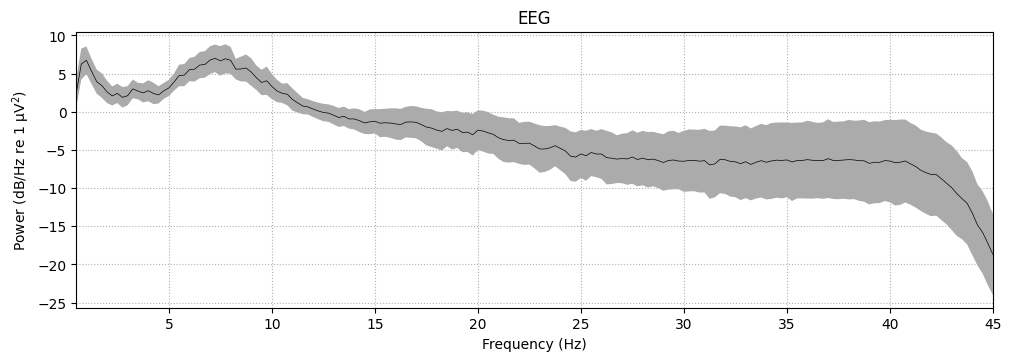

In [14]:
if len(df_inv) == 0:
    raise RuntimeError("Nenhum arquivo .set encontrado.")

exemplo = df_inv.iloc[0].copy()
print(f"Sujeito-exemplo: {exemplo['sample_id']} | {exemplo['grupo']} | {exemplo['pais']} | {exemplo['arquivo_original']}")

raw_bruto = mne.io.read_raw_eeglab(exemplo["caminho_original"], preload=True, verbose=False)
raw_bruto.pick_types(eeg=True, stim=False)

print(f"Fs bruto: {raw_bruto.info['sfreq']} Hz")
print(f"Canais: {raw_bruto.info['nchan']}")
print(f"Duração: {raw_bruto.times[-1]:.2f} s")

raw_bruto.plot_psd(fmin=0.5, fmax=45, average=True, show=True, picks="eeg")
plt.show()

Canais ruins detectados: ['B29', 'B30']


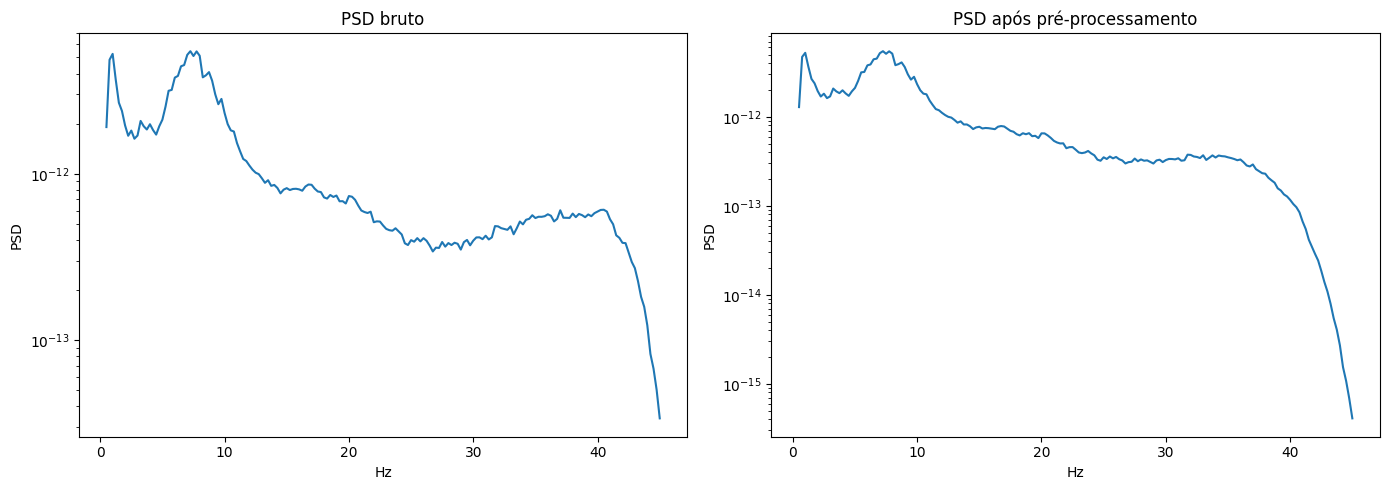

Componentes ICA removidos no exemplo: []
Épocas geradas: 156
Épocas aprovadas: 156
Shape final: (156, 128, 1025)


In [15]:
raw_pp = mne.io.read_raw_eeglab(exemplo["caminho_original"], preload=True, verbose=False)
raw_pp.pick_types(eeg=True, stim=False)

raw_pp.set_eeg_reference("average", projection=False, verbose=False)

raw_pp.filter(
    l_freq=FILTRO_HP,
    h_freq=FILTRO_LP,
    method="iir",
    iir_params=dict(order=ORDEM_FILTRO, ftype="butter"),
    phase="zero",
    verbose=False,
)

if raw_pp.info["sfreq"] != SFREQ_ALVO:
    raw_pp.resample(SFREQ_ALVO, verbose=False)

bads_ex = detectar_canais_ruins(raw_pp)
raw_pp.info["bads"] = bads_ex
if bads_ex:
    raw_pp.interpolate_bads(method="spline", verbose=False)

print(f"Canais ruins detectados: {bads_ex if bads_ex else 'nenhum'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

psd0 = raw_bruto.compute_psd(fmin=0.5, fmax=45)
p0, f0 = psd0.get_data(return_freqs=True)
axes[0].semilogy(f0, p0.mean(axis=0))
axes[0].set_title("PSD bruto")
axes[0].set_xlabel("Hz")
axes[0].set_ylabel("PSD")

psd1 = raw_pp.compute_psd(fmin=0.5, fmax=45)
p1, f1 = psd1.get_data(return_freqs=True)
axes[1].semilogy(f1, p1.mean(axis=0))
axes[1].set_title("PSD após pré-processamento")
axes[1].set_xlabel("Hz")
axes[1].set_ylabel("PSD")

plt.tight_layout()
plt.show()

n_comp_ex = min(N_COMPONENTES_ICA, raw_pp.info["nchan"] - 1)
ica_ex = mne.preprocessing.ICA(
    n_components=n_comp_ex,
    method="infomax",
    fit_params=dict(extended=True),
    random_state=RANDOM_STATE,
    verbose=False,
)
ica_ex.fit(raw_pp, verbose=False)

canais_proxy = [c for c in raw_pp.ch_names if c.lower() in ("fp1", "fp2", "af3", "af4")]
componentes_eog_ex = []
if canais_proxy:
    try:
        idx, scores = ica_ex.find_bads_eog(raw_pp, ch_name=canais_proxy[0], verbose=False)
        componentes_eog_ex = list(idx)
    except Exception:
        componentes_eog_ex = []

ica_ex.exclude = componentes_eog_ex
print(f"Componentes ICA removidos no exemplo: {componentes_eog_ex}")

raw_ica = raw_pp.copy()
ica_ex.apply(raw_ica, verbose=False)

eventos_ex = mne.make_fixed_length_events(raw_ica, duration=DURACAO_EPOC, overlap=0.0)
epocas_ex = mne.Epochs(
    raw_ica,
    eventos_ex,
    tmin=0.0,
    tmax=DURACAO_EPOC,
    baseline=None,
    preload=True,
    verbose=False,
)

n_antes = len(epocas_ex)
epocas_ex.drop_bad(reject={"eeg": LIMIAR_P2P}, verbose=False)
n_depois = len(epocas_ex)

print(f"Épocas geradas: {n_antes}")
print(f"Épocas aprovadas: {n_depois}")
print(f"Shape final: {epocas_ex.get_data().shape}")

assert epocas_ex.info["sfreq"] == SFREQ_ALVO, "Fs final incorreto."
assert epocas_ex.get_data().shape[2] == int(DURACAO_EPOC * SFREQ_ALVO) + 1, "Janela temporal inesperada."

## 4 — Processamento em lote

O lote inteiro é processado sem usar variáveis de classificação como feature.

In [16]:
logs = []
total = len(df_inv)

print(f"Iniciando processamento de {total} sujeitos...")
inicio = datetime.now()

for i, row in df_inv.iterrows():
    log = preprocessar_sujeito(row)
    logs.append(log)

    if log["status"] == "OK":
        print(f"[{i+1:>3}/{total}] {log['sample_id']} -> OK | {log['epocas_aproveitadas']} épocas | {log['canais_ruins_n']} canais ruins")
    else:
        print(f"[{i+1:>3}/{total}] {log['sample_id']} -> ERRO | {log['erro']}")

duracao = (datetime.now() - inicio).total_seconds()
print(f"Tempo total: {duracao/60:.1f} min")

df_log = pd.DataFrame(logs)
df_log.to_csv(LOG_PATH, index=False)
print(f"Log salvo em: {LOG_PATH}")
display(df_log.head(10))

Iniciando processamento de 81 sujeitos...
[  1/81] S0001 -> OK | 156 épocas | 2 canais ruins
[  2/81] S0002 -> OK | 160 épocas | 0 canais ruins
[  3/81] S0003 -> OK | 142 épocas | 2 canais ruins
[  4/81] S0004 -> OK | 157 épocas | 1 canais ruins
[  5/81] S0005 -> OK | 202 épocas | 3 canais ruins
[  6/81] S0006 -> OK | 70 épocas | 0 canais ruins
[  7/81] S0007 -> OK | 113 épocas | 0 canais ruins
[  8/81] S0008 -> OK | 185 épocas | 1 canais ruins
[  9/81] S0009 -> OK | 80 épocas | 0 canais ruins
[ 10/81] S0010 -> OK | 124 épocas | 1 canais ruins
[ 11/81] S0011 -> OK | 211 épocas | 2 canais ruins
[ 12/81] S0012 -> OK | 172 épocas | 3 canais ruins
[ 13/81] S0013 -> OK | 208 épocas | 1 canais ruins
[ 14/81] S0014 -> OK | 198 épocas | 3 canais ruins
[ 15/81] S0015 -> OK | 227 épocas | 0 canais ruins
[ 16/81] S0016 -> OK | 206 épocas | 4 canais ruins
[ 17/81] S0017 -> OK | 218 épocas | 4 canais ruins
[ 18/81] S0018 -> OK | 289 épocas | 0 canais ruins
[ 19/81] S0019 -> OK | 310 épocas | 2 cana

,sample_id,grupo,label,pais,arquivo_original,caminho_original,caminho_saida,status,sfreq_original,duracao_s,canais_ruins_n,canais_ruins,componentes_ica_removidos,epocas_total,epocas_rejeitadas,epocas_aproveitadas,erro
0,S0001,AD,1,AR,s6_sub-30001_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,312.441406,2,"[B29, B30]",[],156,0,156,NaN
1,S0002,AD,1,AR,s6_sub-30002_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,323.306641,0,[],[],161,1,160,NaN
2,S0003,AD,1,AR,s6_sub-30004_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,285.003906,2,"[C4, C8]",[],142,0,142,NaN
3,S0004,AD,1,AR,s6_sub-30008_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,314.316406,1,[D32],[],157,0,157,NaN
4,S0005,AD,1,AR,s6_sub-30009_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,404.359375,3,"[C14, D9, D30]",[],202,0,202,NaN
5,S0006,AD,1,AR,s6_sub-30011_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,141.248047,0,[],[],70,0,70,NaN
6,S0007,AD,1,AR,s6_sub-30012_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,227.763672,0,[],[],113,0,113,NaN
7,S0008,AD,1,AR,s6_sub-30013_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,370.642578,1,[C13],[],185,0,185,NaN
8,S0009,AD,1,AR,s6_sub-30015_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,161.605469,0,[],[],80,0,80,NaN
9,S0010,AD,1,AR,s6_sub-30017_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,OK,512.0,249.843750,1,[B10],[],124,0,124,NaN


In [17]:
assert len(df_log) == len(df_inv), "Quantidade de logs diferente do inventário."
assert set(df_log["status"].unique()).issubset({"OK", "ERRO"}), "Status inválido no log."

df_ok = df_log[df_log["status"] == "OK"].copy()
df_err = df_log[df_log["status"] == "ERRO"].copy()

print(f"Sucesso: {len(df_ok)} / {len(df_log)}")
print(f"Erros: {len(df_err)} / {len(df_log)}")

if len(df_err) > 0:
    display(df_err[["sample_id", "arquivo_original", "erro"]].head(20))

Sucesso: 67 / 81
Erros: 14 / 81


,sample_id,arquivo_original,erro
56,S0057,s6_sub-100013_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
60,S0061,s6_sub-100019_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
63,S0064,s6_sub-100023_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
64,S0065,s6_sub-100025_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
65,S0066,s6_sub-100027_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
67,S0068,s6_sub-100032_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
69,S0070,s6_sub-100036_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
71,S0072,s6_sub-100039_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
72,S0073,s6_sub-100040_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...
73,S0074,s6_sub-100041_rs_eeg.set,File C:\Users\tiago\Downloads\Dataset_EEG_Alzh...


## 5 — Relatório de qualidade

Apenas estatísticas de controle.

RELATÓRIO DE QUALIDADE
Processados com sucesso : 67
Falhas                  : 14
Canais ruins (média ± DP): 1.40 ± 1.14
Épocas aprovadas        : 222.01 ± 64.22
Taxa de rejeição        : 0.02%


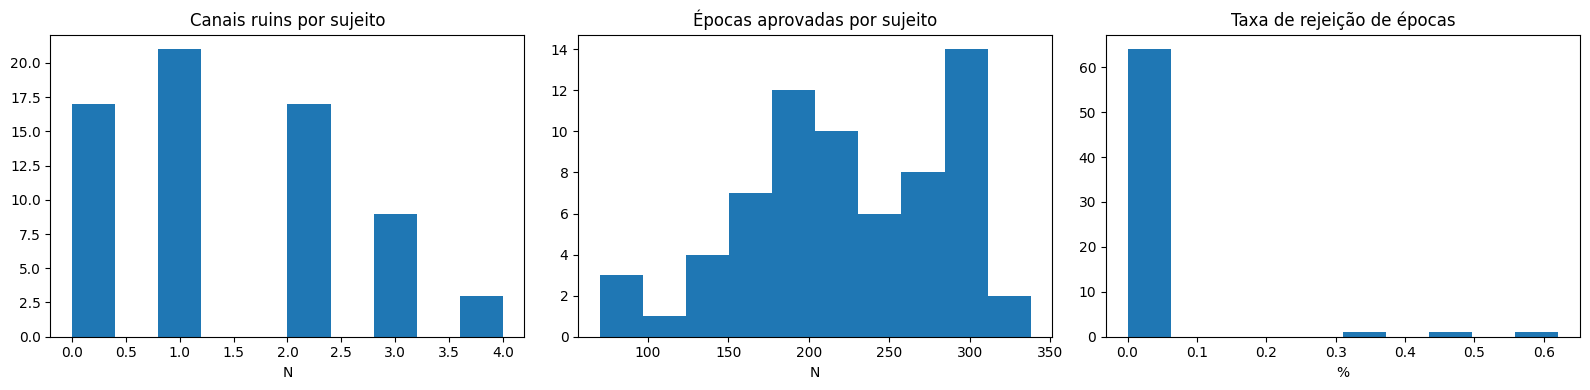

In [18]:
if len(df_ok) == 0:
    raise RuntimeError("Nenhum sujeito foi processado com sucesso.")

print("=" * 70)
print("RELATÓRIO DE QUALIDADE")
print("=" * 70)
print(f"Processados com sucesso : {len(df_ok)}")
print(f"Falhas                  : {len(df_err)}")
print(f"Canais ruins (média ± DP): {df_ok['canais_ruins_n'].mean():.2f} ± {df_ok['canais_ruins_n'].std():.2f}")
print(f"Épocas aprovadas        : {df_ok['epocas_aproveitadas'].mean():.2f} ± {df_ok['epocas_aproveitadas'].std():.2f}")
print(f"Taxa de rejeição        : {(df_ok['epocas_rejeitadas'] / df_ok['epocas_total'].replace(0, np.nan) * 100).mean():.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_ok["canais_ruins_n"], bins=10)
axes[0].set_title("Canais ruins por sujeito")
axes[0].set_xlabel("N")

axes[1].hist(df_ok["epocas_aproveitadas"], bins=10)
axes[1].set_title("Épocas aprovadas por sujeito")
axes[1].set_xlabel("N")

taxa = (df_ok["epocas_rejeitadas"] / df_ok["epocas_total"].replace(0, np.nan) * 100).dropna()
axes[2].hist(taxa, bins=10)
axes[2].set_title("Taxa de rejeição de épocas")
axes[2].set_xlabel("%")

plt.tight_layout()
plt.show()

## 6 — Testes de sanidade dos arquivos salvos

Garante que a saída está pronta para ML sem labels embutidos no nome.

In [19]:
fifiles = sorted(EPOCHS_ROOT.rglob("*-epo.fif"))
print(f"Arquivos .fif encontrados: {len(fifiles)}")
assert len(fifiles) == len(df_ok), "Número de arquivos salvos diferente do número de sucessos."

for fif_path in fifiles[:min(3, len(fifiles))]:
    ep = mne.read_epochs(str(fif_path), verbose=False)
    data = ep.get_data()
    print(f"\n{fif_path.name}")
    print(f"  shape      : {data.shape}")
    print(f"  sfreq      : {ep.info['sfreq']}")
    print(f"  duração    : {data.shape[-1] / ep.info['sfreq']:.2f} s")
    print(f"  amplitude  : {np.max(np.abs(data))*1e6:.2f} µV")
    assert ep.info["sfreq"] == SFREQ_ALVO, "Fs incorreto no arquivo salvo."
    assert "AD" not in fif_path.name and "HC" not in fif_path.name, "Rótulo vazando no nome do arquivo."

print("\nSanidade dos arquivos salvos OK.")

Arquivos .fif encontrados: 67

S0001-epo.fif
  shape      : (156, 128, 1025)
  sfreq      : 512.0
  duração    : 2.00 s
  amplitude  : 65.14 µV

S0002-epo.fif
  shape      : (160, 128, 1025)
  sfreq      : 512.0
  duração    : 2.00 s
  amplitude  : 66.15 µV

S0003-epo.fif
  shape      : (142, 128, 1025)
  sfreq      : 512.0
  duração    : 2.00 s
  amplitude  : 41.37 µV

Sanidade dos arquivos salvos OK.


## 7 — Manifesto final para classificação

O modelo de ML deve usar:
- `X`: features extraídas dos epochs;
- `y`: `label`;
- `groups`: identificador de sujeito.

Nunca usar `caminho_original`, `arquivo_original`, `grupo` ou `pais` como feature direta.

In [20]:
manifesto = df_log.copy()

manifesto = manifesto[[
    "sample_id",
    "grupo",
    "label",
    "pais",
    "arquivo_original",
    "caminho_original",
    "caminho_saida",
    "sfreq_original",
    "duracao_s",
    "canais_ruins_n",
    "epocas_total",
    "epocas_rejeitadas",
    "epocas_aproveitadas",
    "status",
    "erro",
]].copy()

manifesto.to_csv(MANIFEST_PATH, index=False)
print(f"Manifesto salvo em: {MANIFEST_PATH}")
display(manifesto.head(10))

assert manifesto["sample_id"].is_unique, "sample_id duplicado no manifesto."
assert set(manifesto["label"].unique()).issubset({0, 1}), "Labels inválidos."
assert manifesto["caminho_saida"].dropna().apply(lambda x: "AD" not in Path(x).name and "HC" not in Path(x).name).all(),     "Label vazando no nome de saída."

print("Manifesto OK.")

Manifesto salvo em: C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer\preprocessado_seguros\manifesto_preprocessado.csv


,sample_id,grupo,label,pais,arquivo_original,caminho_original,caminho_saida,sfreq_original,duracao_s,canais_ruins_n,epocas_total,epocas_rejeitadas,epocas_aproveitadas,status,erro
0,S0001,AD,1,AR,s6_sub-30001_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,312.441406,2,156,0,156,OK,NaN
1,S0002,AD,1,AR,s6_sub-30002_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,323.306641,0,161,1,160,OK,NaN
2,S0003,AD,1,AR,s6_sub-30004_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,285.003906,2,142,0,142,OK,NaN
3,S0004,AD,1,AR,s6_sub-30008_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,314.316406,1,157,0,157,OK,NaN
4,S0005,AD,1,AR,s6_sub-30009_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,404.359375,3,202,0,202,OK,NaN
5,S0006,AD,1,AR,s6_sub-30011_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,141.248047,0,70,0,70,OK,NaN
6,S0007,AD,1,AR,s6_sub-30012_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,227.763672,0,113,0,113,OK,NaN
7,S0008,AD,1,AR,s6_sub-30013_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,370.642578,1,185,0,185,OK,NaN
8,S0009,AD,1,AR,s6_sub-30015_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,161.605469,0,80,0,80,OK,NaN
9,S0010,AD,1,AR,s6_sub-30017_rs-hep_eeg.set,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,C:\Users\tiago\Downloads\Dataset_EEG_Alzheimer...,512.0,249.843750,1,124,0,124,OK,NaN


Manifesto OK.


## 8 — Esqueleto do pipeline de classificação sem vazamento

Estrutura-base para a próxima etapa:
- `GroupKFold` ou `StratifiedGroupKFold`;
- `fit` apenas no treino;
- features retiradas somente do sinal;
- metadados nunca entram em `X`.

In [21]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

def extrair_features_simples(caminho_fif: str) -> np.ndarray:
    epochs = mne.read_epochs(caminho_fif, verbose=False)
    psd = epochs.compute_psd(fmin=0.5, fmax=40.0, verbose=False)
    psd_data, freqs = psd.get_data(return_freqs=True)

    bandas = {
        "delta": (0.5, 4.0),
        "theta": (4.0, 8.0),
        "alpha": (8.0, 13.0),
        "beta": (13.0, 30.0),
        "low_gamma": (30.0, 40.0),
    }

    feats = []
    for ep_idx in range(psd_data.shape[0]):
        feat_ep = []
        spec = psd_data[ep_idx]
        for _, (fmin, fmax) in bandas.items():
            mask = (freqs >= fmin) & (freqs < fmax)
            band_pow = spec[:, mask].mean(axis=1)
            feat_ep.append(band_pow)
        feats.append(np.concatenate(feat_ep))

    return np.vstack(feats)

X_list, y_list, g_list = [], [], []

for _, row in manifesto[manifesto["status"] == "OK"].iterrows():
    feats = extrair_features_simples(row["caminho_saida"])
    labels = np.repeat(int(row["label"]), feats.shape[0])
    groups = np.repeat(row["sample_id"], feats.shape[0])

    X_list.append(feats)
    y_list.append(labels)
    g_list.append(groups)

X = np.vstack(X_list)
y = np.concatenate(y_list)
groups = np.concatenate(g_list)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

cv = GroupKFold(n_splits=5)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

scores = []
for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
    X_tr, X_te = X[tr], X[te]
    y_tr, y_te = y[tr], y[te]

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    prob = pipe.predict_proba(X_te)[:, 1]

    bac = balanced_accuracy_score(y_te, pred)
    auc = roc_auc_score(y_te, prob)
    scores.append((bac, auc))

    print(f"Fold {fold}: BAC={bac:.3f} | AUC={auc:.3f}")

scores = np.array(scores)
print(f"\nBAC médio: {scores[:,0].mean():.3f} ± {scores[:,0].std():.3f}")
print(f"AUC médio: {scores[:,1].mean():.3f} ± {scores[:,1].std():.3f}")

X shape: (14875, 640)
y shape: (14875,)
groups shape: (14875,)
Fold 1: BAC=1.000 | AUC=1.000
Fold 2: BAC=0.992 | AUC=0.998
Fold 3: BAC=0.972 | AUC=1.000
Fold 4: BAC=1.000 | AUC=1.000
Fold 5: BAC=0.932 | AUC=1.000

BAC médio: 0.979 ± 0.026
AUC médio: 0.999 ± 0.001
